# DeepLense Common Test I: Multi-Class Classification

This notebook presents a deep learning approach for classifying strong gravitational lensing images into three categories:
- No substructure
- Sphere (subhalo substructure)
- Vortex substructure

The objective is to build a multi-class classifier and evaluate performance using ROC curves and AUC scores.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [36]:
train_size = len(train_dataset)
val_size = len(val_dataset)

total = train_size + val_size

print("Train size:", train_size)
print("Validation size:", val_size)
print("Train %:", train_size/total)
print("Validation %:", val_size/total)

Train size: 27000
Validation size: 3000
Train %: 0.9
Validation %: 0.1


## Dataset Description

The dataset consists of simulated strong gravitational lensing images categorized into:
- `no`
- `sphere`
- `vort`

The dataset was provided with predefined `train` and `val` folders.  
We verified that this split approximately corresponds to a 90:10 ratio.

All images are resized to 224×224 for compatibility with the ResNet50 architecture.

In [5]:
import os
os.listdir("/content/dataset/dataset")

['train', '.DS_Store', 'val']

In [6]:
os.listdir("/content/dataset/dataset/train")

['sphere', 'vort', 'no', '.DS_Store']

In [7]:
os.listdir("/content/dataset/dataset/val")

['sphere', 'vort', 'no', '.DS_Store']

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

In [13]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [14]:
class LensDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

In [16]:
data_dir = "/content/dataset/dataset"
train_dir = os.path.join(data_dir, "train")
class_names = ['no', 'sphere', 'vort']

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    files = os.listdir(class_path)
    npy_files = [f for f in files if f.endswith('.npy')]
    print(f"\n{class_name}: {len(npy_files)} .npy files")

    if npy_files:
        sample = np.load(os.path.join(class_path, npy_files[0]))
        print(f"  Sample shape: {sample.shape}")
        print(f"  Data type: {sample.dtype}")
        print(f"  Value range: [{sample.min():.3f}, {sample.max():.3f}]")


no: 10000 .npy files
  Sample shape: (1, 150, 150)
  Data type: float64
  Value range: [0.000, 1.000]

sphere: 10000 .npy files
  Sample shape: (1, 150, 150)
  Data type: float64
  Value range: [0.000, 1.000]

vort: 10000 .npy files
  Sample shape: (1, 150, 150)
  Data type: float64
  Value range: [0.000, 1.000]


In [17]:
class LensDatasetNPY(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_array = np.load(self.file_paths[idx])

        if img_array.ndim == 2:
            img_array = np.expand_dims(img_array, axis=-1)

        if img_array.shape[0] in [1, 3] and img_array.ndim == 3:
            img_array = np.transpose(img_array, (1, 2, 0))

        if img_array.max() > 1.0:
            img_array = img_array.astype(np.float32)
        else:
            img_array = img_array.astype(np.float32)

        if img_array.shape[-1] == 1:
            img_array = np.repeat(img_array, 3, axis=-1)

        img_array = (img_array * 255).astype(np.uint8)
        image = Image.fromarray(img_array)

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

In [18]:
file_paths = []
labels = []

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    npy_files = [f for f in os.listdir(class_path) if f.endswith('.npy')]

    for npy_file in npy_files:
        file_paths.append(os.path.join(class_path, npy_file))
        labels.append(class_to_idx[class_name])

print(f"Total samples: {len(file_paths)}")
print(f"\nClass distribution:")
for class_name in class_names:
    count = labels.count(class_to_idx[class_name])
    print(f"  {class_name}: {count} ({count/len(labels)*100:.1f}%)")

Total samples: 30000

Class distribution:
  no: 10000 (33.3%)
  sphere: 10000 (33.3%)
  vort: 10000 (33.3%)


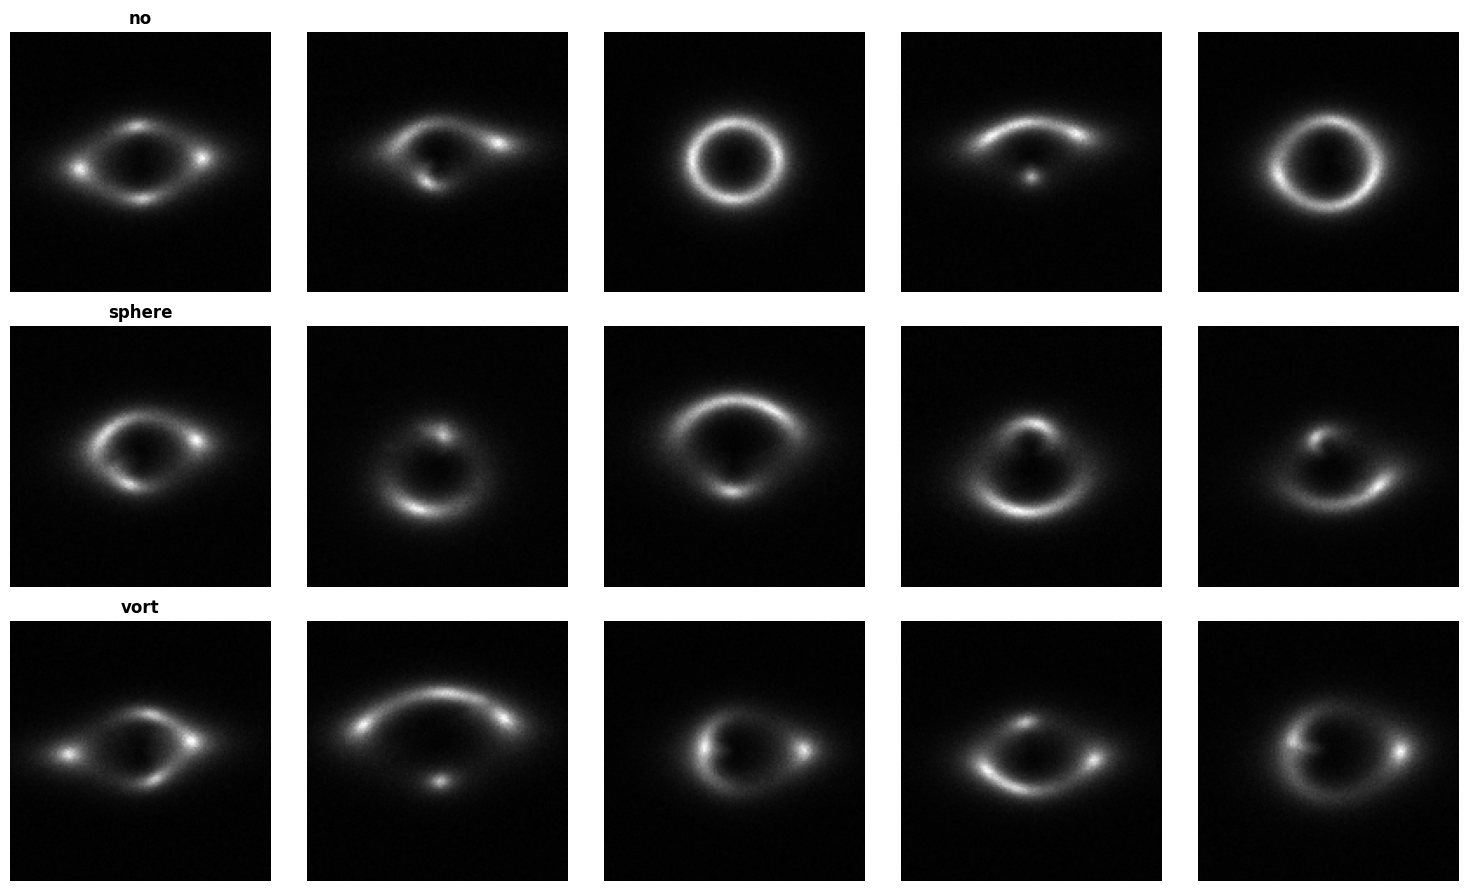

In [19]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, class_name in enumerate(class_names):
    class_idx = class_to_idx[class_name]
    class_files = [file_paths[j] for j in range(len(file_paths)) if labels[j] == class_idx]
    samples = np.random.choice(class_files, 5, replace=False)

    for j, sample_path in enumerate(samples):
        img = np.load(sample_path)

        if img.ndim == 3 and img.shape[0] in [1, 3]:
            img = np.transpose(img, (1, 2, 0))
        if img.ndim == 2:
            img = np.expand_dims(img, axis=-1)

        axes[i, j].imshow(img.squeeze(), cmap='gray' if img.shape[-1] == 1 else None)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f'{class_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.1, random_state=42, stratify=labels
)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

train_dataset = LensDatasetNPY(train_paths, train_labels, transform=train_transform)
val_dataset = LensDatasetNPY(val_paths, val_labels, transform=val_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 27000
Validation samples: 3000


## Model Architecture

We use transfer learning with a pretrained ResNet50 model.

ResNet50 was selected due to its deeper architecture, enabling stronger hierarchical feature extraction for subtle morphological differences in lensing patterns.

To prevent overfitting while retaining adaptability:
- Early convolutional layers are frozen.
- Later layers (layer3, layer4) are fine-tuned.
- A custom fully connected classifier head is added.

The classifier head consists of:
- Linear layer (512 units) + ReLU + BatchNorm + Dropout (0.5)
- Linear layer (256 units) + ReLU + BatchNorm + Dropout (0.3)
- Final linear layer (3 outputs)

This design improves regularization and allows better separation of complex substructure features.

In [27]:
model = models.resnet50(pretrained=True)
for name, param in model.named_parameters():
    if 'layer4' in name or 'layer3' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.3),
    nn.Linear(256, 3)
)

model = model.to(device)

print("✅ Improved model loaded!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Improved model loaded!
Total parameters: 24,690,755
Trainable parameters: 23,245,827


## Training Configuration

### Loss Function
We use CrossEntropyLoss, which is appropriate for multi-class classification problems.

### Differential Learning Rates
To enable controlled fine-tuning, different learning rates are assigned to different parts of the network:

- layer3 → 1e-4  
- layer4 → 5e-4  
- Fully connected classifier → 1e-3  

This strategy allows:
- Smaller updates to earlier feature representations
- Larger updates to the newly added classification head
- Stable convergence during fine-tuning

### Optimizer
Adam optimizer is used with weight decay (1e-4) for regularization.

### Learning Rate Scheduler
ReduceLROnPlateau is employed to automatically reduce the learning rate when validation loss stops improving.

- Factor: 0.3  
- Patience: 2 epochs  

This prevents stagnation and helps the model converge more effectively.

### Training Details
- Number of epochs: 15  
- Batch size: 32  
- Best model checkpoint saved based on validation accuracy  

In [28]:
criterion = nn.CrossEntropyLoss()
trainable_params = [
    {'params': model.layer3.parameters(), 'lr': 0.0001},
    {'params': model.layer4.parameters(), 'lr': 0.0005},
    {'params': model.fc.parameters(), 'lr': 0.001}
]

optimizer = optim.Adam(trainable_params, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2
)

In [30]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        if (batch_idx + 1) % 100 == 0:
            print(f'  Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_preds.append(predicted.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    all_probs = np.vstack(all_probs)
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)

    return epoch_loss, epoch_acc, all_probs, all_labels, all_preds

print("✅ Training and validation functions defined!")

✅ Training and validation functions defined!


In [31]:
num_epochs = 15
best_val_acc = 0.0
current_lr = optimizer.param_groups[0]['lr']

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print('='*50)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    val_loss, val_acc, val_probs, val_labels, val_preds = validate(
        model, val_loader, criterion, device
    )

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if old_lr != new_lr:
        print(f"⚠️  Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {new_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, 'best_lens_classifier.pth')
        print(f"✓ Model saved! (Best Val Acc: {best_val_acc:.2f}%)")

print(f"\n{'='*50}")
print(f"Training completed!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print('='*50)


Epoch 1/15
  Batch 100/844 | Loss: 1.0600
  Batch 200/844 | Loss: 1.2402
  Batch 300/844 | Loss: 1.2008
  Batch 400/844 | Loss: 1.1066
  Batch 500/844 | Loss: 1.1842
  Batch 600/844 | Loss: 1.0442
  Batch 700/844 | Loss: 1.0377
  Batch 800/844 | Loss: 0.9891

Train Loss: 1.1277 | Train Acc: 34.97%
Val Loss: 1.0684 | Val Acc: 41.43%
Learning Rate: 0.000100
✓ Model saved! (Best Val Acc: 41.43%)

Epoch 2/15
  Batch 100/844 | Loss: 1.0249
  Batch 200/844 | Loss: 1.0181
  Batch 300/844 | Loss: 1.0690
  Batch 400/844 | Loss: 0.9933
  Batch 500/844 | Loss: 0.9260
  Batch 600/844 | Loss: 1.0322
  Batch 700/844 | Loss: 1.0136
  Batch 800/844 | Loss: 0.8508

Train Loss: 1.0076 | Train Acc: 46.83%
Val Loss: 0.9449 | Val Acc: 51.83%
Learning Rate: 0.000100
✓ Model saved! (Best Val Acc: 51.83%)

Epoch 3/15
  Batch 100/844 | Loss: 1.0931
  Batch 200/844 | Loss: 0.9439
  Batch 300/844 | Loss: 0.9560
  Batch 400/844 | Loss: 1.0309
  Batch 500/844 | Loss: 0.9001
  Batch 600/844 | Loss: 0.8566
  Batch 

## Training Results

The model was trained for 15 epochs using partial fine-tuning of ResNet50.

The best-performing model was selected based on validation accuracy and saved during training.

Below, we analyze the training dynamics and evaluation metrics.

### Training and Validation Curves

To assess convergence and generalization behavior, we plot:

- Training vs Validation Loss
- Training vs Validation Accuracy

These curves help evaluate:
- Stability of optimization
- Presence of overfitting
- Effectiveness of learning rate scheduling

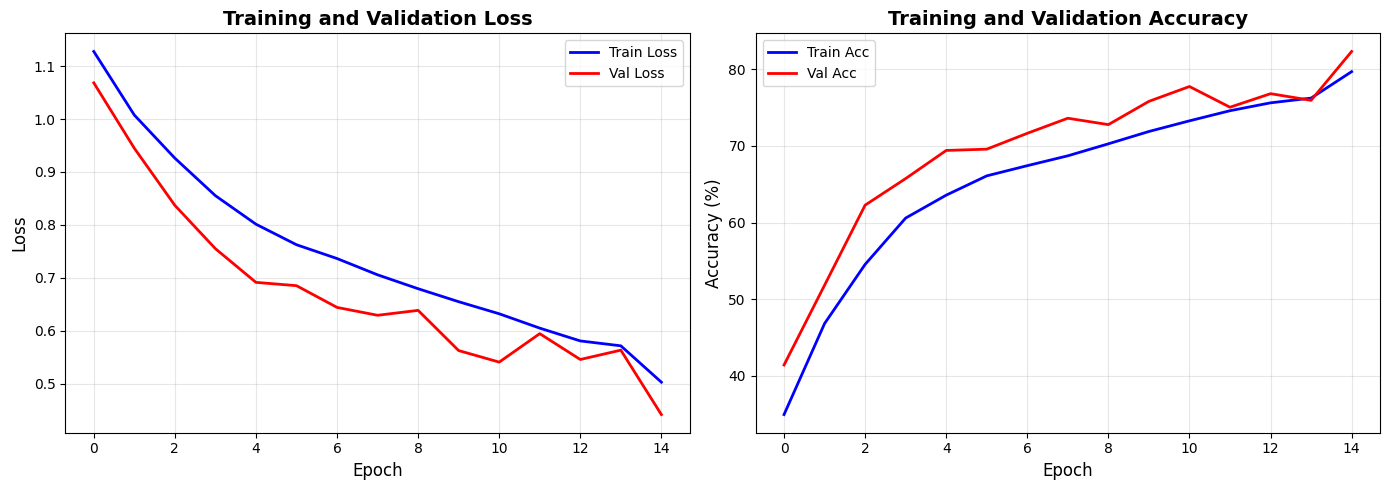

✅ Training history plot saved!


In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], 'r-', label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], 'b-', label='Train Acc', linewidth=2)
plt.plot(history['val_acc'], 'r-', label='Val Acc', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=10)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plot saved!")

## ROC Curve and AUC Evaluation

To evaluate class separability, we compute Receiver Operating Characteristic (ROC) curves using a One-vs-Rest strategy.

For each class:
- True Positive Rate (TPR) and False Positive Rate (FPR) are computed.
- Area Under the Curve (AUC) is calculated.

We also compute the macro-average AUC to summarize overall discriminative performance.

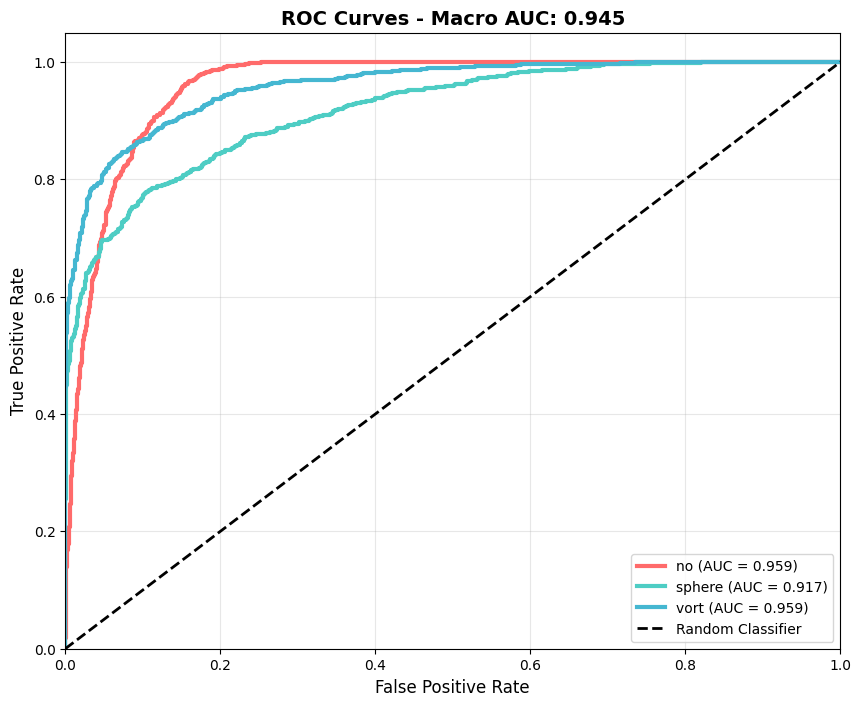


EVALUATION METRICS
Validation Accuracy: 82.30%
Macro-Average AUC Score: 0.9452

Per-Class AUC Scores:
  no         AUC: 0.9595
  sphere     AUC: 0.9172
  vort       AUC: 0.9590


In [33]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
checkpoint = torch.load('best_lens_classifier.pth')
model.load_state_dict(checkpoint['model_state_dict'])
val_loss, val_acc, val_probs, val_labels, val_preds = validate(
    model, val_loader, criterion, device
)

val_labels_bin = label_binarize(val_labels, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
class_names = ['no', 'sphere', 'vort']

for i, class_name in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(val_labels_bin[:, i], val_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=3,
             label=f'{class_name} (AUC = {roc_auc[i]:.3f})')
macro_auc = roc_auc_score(val_labels_bin, val_probs, average='macro')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curves - Macro AUC: {macro_auc:.3f}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print("EVALUATION METRICS")
print('='*50)
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Macro-Average AUC Score: {macro_auc:.4f}")
print("\nPer-Class AUC Scores:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name:10s} AUC: {roc_auc[i]:.4f}")
print('='*50)

## Performance Summary

Validation Accuracy: 82.30%

Macro-Average AUC: 0.9452

Per-Class AUC:
- no: 0.9595
- sphere: 0.9172
- vort: 0.9590

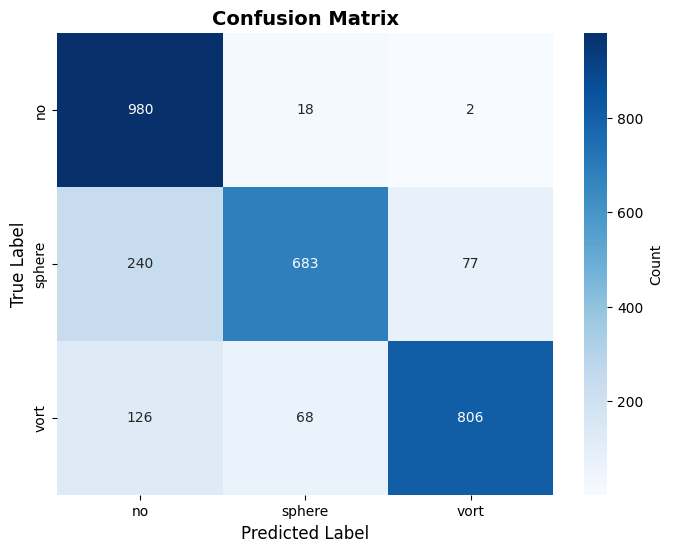


CLASSIFICATION REPORT
              precision    recall  f1-score   support

          no     0.7281    0.9800    0.8355      1000
      sphere     0.8882    0.6830    0.7722      1000
        vort     0.9107    0.8060    0.8552      1000

    accuracy                         0.8230      3000
   macro avg     0.8423    0.8230    0.8209      3000
weighted avg     0.8423    0.8230    0.8209      3000



In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(val_labels, val_preds, target_names=class_names, digits=4))

## Classification Analysis

The classification report provides detailed precision, recall, and F1-scores for each class.

Key observations:

- The `no` class achieves very high recall (0.98), indicating strong sensitivity in detecting absence of substructure.
- The `sphere` class shows comparatively lower recall (0.6830), suggesting that sphere-type substructures may share morphological similarities with other classes.
- The `vort` class demonstrates balanced precision and recall, indicating effective recognition of vortex patterns.

In [35]:
with open('results.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("GRAVITATIONAL LENS CLASSIFICATION RESULTS\n")
    f.write("="*60 + "\n\n")
    f.write("MODEL CONFIGURATION:\n")
    f.write("-" * 60 + "\n")
    f.write("Architecture: ResNet50 (Transfer Learning)\n")
    f.write("Training Epochs: 15\n")
    f.write(f"Final Epoch: {len(history['train_acc'])}\n")
    f.write("Optimizer: Adam with discriminative learning rates\n")
    f.write("Data Augmentation: Horizontal/Vertical Flip, Rotation, ColorJitter\n\n")

    f.write("PERFORMANCE METRICS:\n")
    f.write("-" * 60 + "\n")
    f.write(f"Best Validation Accuracy: {best_val_acc:.2f}%\n")
    f.write(f"Final Training Accuracy: {history['train_acc'][-1]:.2f}%\n")
    f.write(f"Final Validation Loss: {history['val_loss'][-1]:.4f}\n")
    f.write(f"Macro-Average AUC: {macro_auc:.4f}\n\n")

    f.write("PER-CLASS AUC SCORES:\n")
    f.write("-" * 60 + "\n")
    for i, class_name in enumerate(class_names):
        f.write(f"  {class_name.upper():10s}: {roc_auc[i]:.4f}\n")

    f.write("\n" + "="*60 + "\n")
    f.write("DETAILED CLASSIFICATION REPORT:\n")
    f.write("="*60 + "\n")
    f.write(classification_report(val_labels, val_preds, target_names=class_names, digits=4))

    f.write("\n" + "="*60 + "\n")
    f.write("CONFUSION MATRIX:\n")
    f.write("="*60 + "\n")
    f.write("           Predicted\n")
    f.write(f"           {'  '.join([f'{c:8s}' for c in class_names])}\n")
    f.write("Actual\n")
    for i, class_name in enumerate(class_names):
        f.write(f"{class_name:8s}   {' '.join([f'{cm[i][j]:8d}' for j in range(len(class_names))])}\n")

print("\n✅ Results saved to 'results.txt'")
print("✅ Plots saved: training_history.png, roc_curves.png, confusion_matrix.png")


✅ Results saved to 'results.txt'
✅ Plots saved: training_history.png, roc_curves.png, confusion_matrix.png


## Discussion and Conclusion

The ResNet50 model with partial fine-tuning achieves strong overall performance, with a macro-average AUC of approximately 0.95.

Differential learning rates and learning rate scheduling contribute to stable convergence and controlled optimization.

The slightly lower performance on the `sphere` class suggests greater visual ambiguity in this category, indicating potential areas for further architectural tuning or interpretability analysis.

Overall, the implementation satisfies the DeepLense Common Test requirements by:
- Training a 3-class classifier
- Evaluating using ROC curves
- Reporting AUC metrics
- Providing detailed classification analysis

This model provides a strong baseline for further research in gravitational lens substructure classification.